[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%209%20Ensemble%20Methods/09-Ensemble-Methods.ipynb)

# Lecture 9: More Models, Different Mistakes

A hundred copies of one opinion are still one opinion. What changes when the models make **different mistakes**? We will follow their votes, build a forest, and ask whether disagreement helps us decide when to pause rather than predict.

We'll start with a simple classification problem, then follow the votes on real [CIFAR-10 images](https://www.cs.toronto.edu/~kriz/cifar.html). Along the way, we'll look at both the decisions a committee improves and the mistakes its members still share.

In [57]:
# @title Colab Setup
import sys
import os
from pathlib import Path
if 'google.colab' in sys.modules:
    import subprocess
    repo = Path('/content/learn-ml-by-building')
    if not repo.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/jinming99/learn-ml-by-building.git', str(repo)], check=True)
    os.chdir(repo / 'Lecture 9 Ensemble Methods')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn', 'torch', 'torchvision', 'ipywidgets'], check=True)
else:
    print('Running locally. Use this lecture folder as the working directory.')

Running locally. Use this lecture folder as the working directory.


In [58]:
import copy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, clear_output
import ipywidgets as widgets
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
import torch
from torch import nn
import torchvision
from torchvision.models import resnet18, ResNet18_Weights

torch.set_num_threads(4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'grid.alpha': .18, 'figure.dpi': 110, 'legend.frameon': False})
BLUE, CORAL, TEAL, INK, MUTED = '#3A86FF', '#E76F51', '#2A9D8F', '#263238', '#8D99AE'

def table(rows, formats=None):
    display(pd.DataFrame(rows).style.hide(axis='index').format(formats or {}, precision=3, na_rep='—'))

def explore(fn, **controls):
    fn(**{k: w.value for k, w in controls.items()})
    button = widgets.Button(description='Explore this figure', icon='sliders', layout=widgets.Layout(width='190px'))
    def activate(_):
        clear_output(wait=True)
        display(widgets.interactive(fn, **controls))
    button.on_click(activate)
    display(button)

def vote_counts(predictions, n_classes):
    return np.eye(n_classes, dtype=int)[np.asarray(predictions)].sum(axis=0)

def entropy(p):
    return -(p * np.log(np.clip(p, 1e-12, 1))).sum(axis=-1)

def uncertainty(probabilities):
    mean = probabilities.mean(axis=0)
    within = entropy(probabilities).mean(axis=0)
    return mean, within, np.maximum(entropy(mean)-within, 0)

## 1. Does Another Copy Help?

If we copy the same tree fifty times, will its decision boundary change? Let's compare that with training trees on different bootstrap samples. They all have depth five and draw from the same training data. The dots below are validation examples; the first three panels show individual members, and the last shows their combined decision.

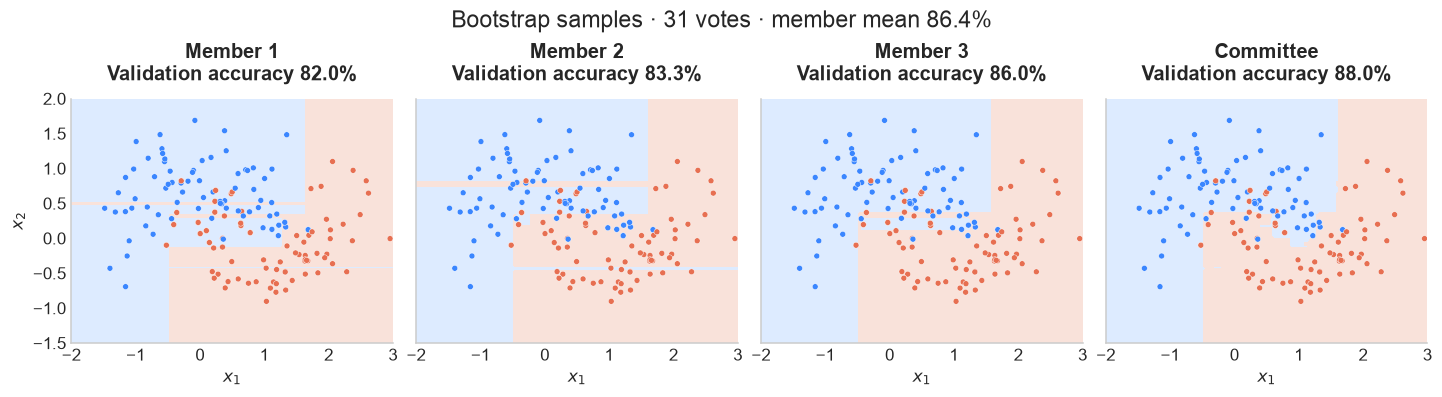

Button(description='Explore this figure', icon='sliders', layout=Layout(width='190px'), style=ButtonStyle())

In [59]:
moon_X, moon_y = make_moons(n_samples=500, noise=.35, random_state=42)
moon_train, moon_val = train_test_split(np.arange(500), test_size=.3, stratify=moon_y, random_state=42)
moon_rng = np.random.default_rng(42)
moon_tree = DecisionTreeClassifier(max_depth=5, random_state=42).fit(moon_X[moon_train], moon_y[moon_train])
moon_bag = []
for seed in range(51):
    ids = moon_rng.choice(moon_train, len(moon_train), replace=True)
    moon_bag.append(DecisionTreeClassifier(max_depth=5, random_state=seed).fit(moon_X[ids], moon_y[ids]))
mx, my = np.meshgrid(np.linspace(-2, 3, 180), np.linspace(-1.5, 2, 150))
moon_mesh = np.c_[mx.ravel(), my.ravel()]

def moon_story(committee='Bootstrap samples', members=31):
    models = moon_bag[:members] if committee == 'Bootstrap samples' else [moon_tree]*members
    member_votes = np.array([m.predict(moon_X[moon_val]) for m in models])
    ensemble_vote = vote_counts(member_votes, 2).argmax(1)
    individual = (member_votes == moon_y[moon_val]).mean(axis=1)
    grid_votes = np.array([m.predict(moon_mesh) for m in models])
    panels = [grid_votes[min(i, members-1)] for i in range(3)] + [vote_counts(grid_votes, 2).argmax(1)]
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), sharex=True, sharey=True, layout='constrained')
    for i, (ax, pred) in enumerate(zip(axes, panels)):
        if i<3 and i>=members:
            ax.axis('off'); ax.text(.5,.5,'No additional member',ha='center',va='center',transform=ax.transAxes,color=MUTED)
            continue
        ax.contourf(mx, my, pred.reshape(mx.shape), levels=[-.5,.5,1.5], colors=['#DDEBFF','#F9E2DA'])
        ax.scatter(*moon_X[moon_val].T, c=np.array([BLUE,CORAL])[moon_y[moon_val]], s=15, edgecolor='white', linewidth=.3)
        acc = individual[min(i,members-1)] if i<3 else (ensemble_vote==moon_y[moon_val]).mean()
        ax.set(title=f'{"Member " + str(min(i,members-1)+1) if i<3 else "Committee"}\nValidation accuracy {acc:.1%}', xlabel='$x_1$', xlim=(-2,3), ylim=(-1.5,2))
    axes[0].set_ylabel('$x_2$')
    fig.suptitle(f'{committee} · {members} {"vote" if members==1 else "votes"} · member mean {individual.mean():.1%}', fontsize=15)
    plt.show()

explore(moon_story, committee=widgets.Dropdown(options=['Bootstrap samples','Copies of one tree'], description='Committee'),
        members=widgets.SelectionSlider(options=[1,3,5,15,31,51], value=31, description='Members', continuous_update=False))

More copies give the same answer more votes, but they don't change it. Bootstrap samples can give us different boundaries. Does combining those trees beat a typical member? Does it beat the best one? Those are different questions.

## 2. One Picture, Many Votes

Now let's try real pictures. We'll use 4,000 images for training and 1,000 for validation, with equal numbers from each class. Another 1,000 images from CIFAR-10's official test set will wait until the final evaluation.

An ImageNet-pretrained ResNet-18 describes each image with 512 numbers. We leave that network unchanged and train our trees on those features. All the trees get the same image description; what differs is how they learn to classify it.

In [60]:
train_data = torchvision.datasets.CIFAR10('data', train=True, download=True)
test_data = torchvision.datasets.CIFAR10('data', train=False, download=True)
class_names = np.array(train_data.classes)
all_y = np.asarray(train_data.targets)
pool_ids, _ = train_test_split(np.arange(len(all_y)), train_size=5000, stratify=all_y, random_state=42)
train_ids, val_ids = train_test_split(pool_ids, test_size=1000, stratify=all_y[pool_ids], random_state=42)
test_ids, _ = train_test_split(np.arange(len(test_data)), train_size=1000, stratify=test_data.targets, random_state=42)
train_images, val_images = train_data.data[train_ids], train_data.data[val_ids]
test_images = test_data.data[test_ids]
y_train, y_val = all_y[train_ids], all_y[val_ids]
weights = ResNet18_Weights.IMAGENET1K_V1
encoder = resnet18(weights=weights).to(device).eval()
encoder.fc = nn.Identity()
preprocess = weights.transforms()
cache_dir = Path('data/ensemble_cache'); cache_dir.mkdir(exist_ok=True)

def embeddings(images):
    version = f'resnet18-v1-official-transform:{torch.__version__}:{torchvision.__version__}'
    key = hashlib.sha256(version.encode() + images.tobytes()).hexdigest()[:20]
    path = cache_dir / f'{key}.npy'
    if path.exists():
        return np.load(path, allow_pickle=False)
    chunks = []
    with torch.inference_mode():
        for start in range(0, len(images), 32):
            x = torch.from_numpy(images[start:start+32].copy()).permute(0,3,1,2)
            chunks.append(encoder(preprocess(x).to(device)).cpu().numpy())
    result = np.concatenate(chunks).astype('float32')
    np.save(path, result)
    return result

X_train, X_val = embeddings(train_images), embeddings(val_images)
scaler = StandardScaler().fit(X_train)
train_scaled = scaler.transform(X_train).astype('float32')
val_scaled = scaler.transform(X_val).astype('float32')
print(f'{len(y_train):,} training · {len(y_val):,} validation · {len(test_ids):,} reserved test images · {X_train.shape[1]} features')

Files already downloaded and verified
Files already downloaded and verified
4,000 training · 1,000 validation · 1,000 reserved test images · 512 features


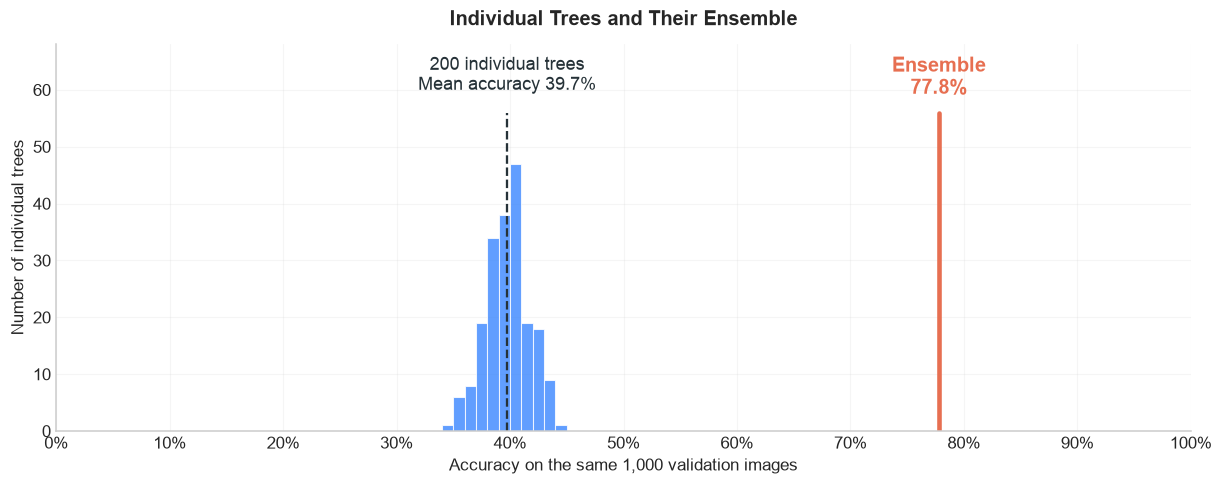

In [61]:
forest = RandomForestClassifier(n_estimators=200, max_features='sqrt', oob_score=True, random_state=42, n_jobs=4).fit(X_train, y_train)
tree_val_votes = np.array([tree.predict(X_val).astype(int) for tree in forest.estimators_])
counts = vote_counts(tree_val_votes, 10)
plurality = counts.argmax(1)
member_accuracies = (tree_val_votes == y_val).mean(axis=1)

ensemble_accuracy = accuracy_score(y_val, plurality)
fig, ax = plt.subplots(figsize=(11, 4.3), layout='constrained')
heights, _, _ = ax.hist(member_accuracies, bins=np.arange(.0, 1.01, .01),
                        color=BLUE, alpha=.8, edgecolor='white', linewidth=.7)
ax.axvline(member_accuracies.mean(), color=INK, ls='--', lw=1.5, ymax=.82)
ax.axvline(ensemble_accuracy, color=CORAL, lw=3, ymax=.82)
ax.text(member_accuracies.mean(), .97,
        f'{len(member_accuracies)} individual trees\nMean accuracy {member_accuracies.mean():.1%}',
        transform=ax.get_xaxis_transform(), ha='center', va='top', color=INK, fontsize=12)
ax.text(ensemble_accuracy, .97, f'Ensemble\n{ensemble_accuracy:.1%}',
        transform=ax.get_xaxis_transform(), ha='center', va='top', color=CORAL, fontsize=13, weight='bold')
ax.set(xlim=(0, 1), ylim=(0, max(heights)*1.45), xlabel='Accuracy on the same 1,000 validation images',
       ylabel='Number of individual trees', title='Individual Trees and Their Ensemble')
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xticks(np.linspace(0, 1, 11))
plt.show()

Every individual tree scores between 34.8% and 44.3%, yet their combined predictions reach 77.8% on the same images. The coral line isn't a particularly good tree—it's the committee. How can the group do better than every one of its members? Let's look inside three decisions.

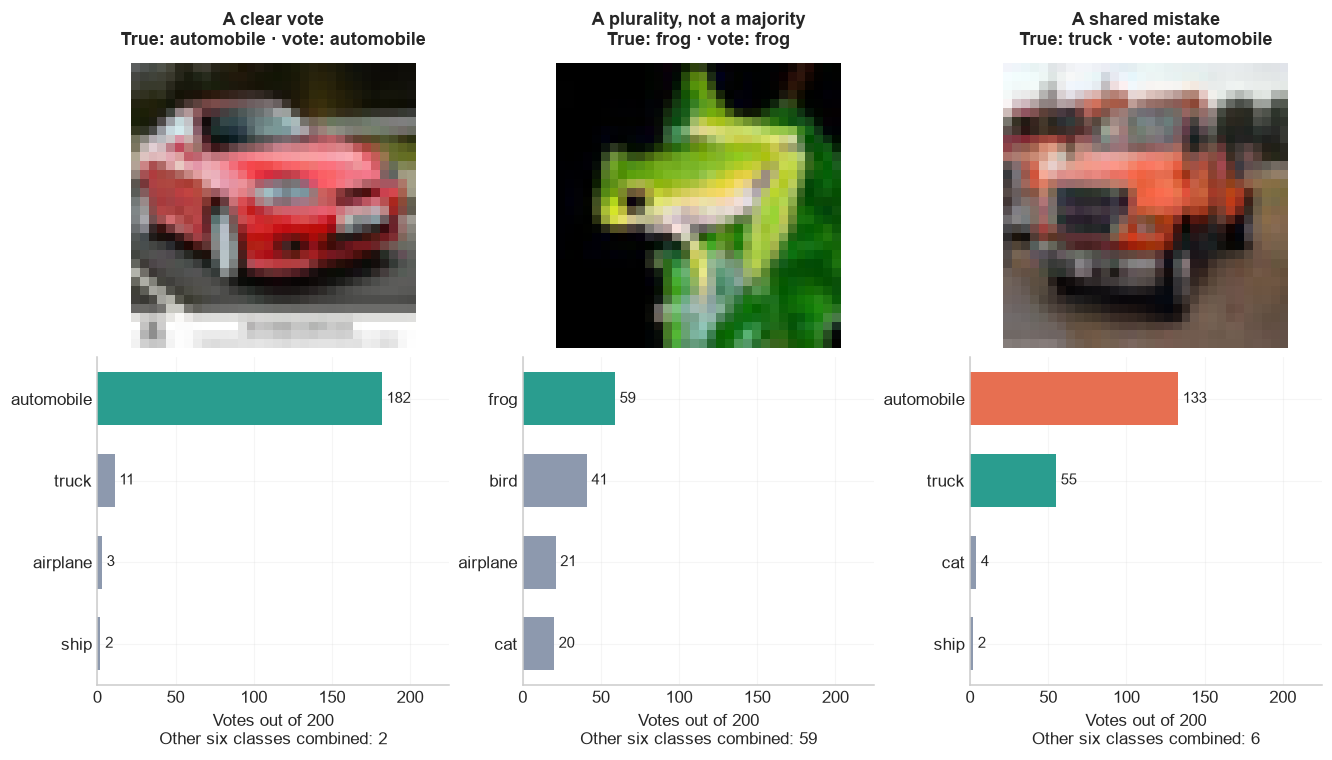

In [62]:
def vote_examples():
    correct = plurality == y_val
    rescued = correct & (counts[np.arange(len(y_val)), y_val] < len(forest.estimators_)/2)
    choices = [np.flatnonzero(correct)[np.argmax(counts[correct].max(1))],
               np.flatnonzero(rescued)[0] if rescued.any() else np.flatnonzero(correct)[0],
               np.flatnonzero(~correct)[np.argmax(counts[~correct].max(1))]]
    titles = ['A clear vote', 'A plurality, not a majority' if rescued.any() else 'Another correct vote', 'A shared mistake']
    fig, axes = plt.subplots(2,3,figsize=(12,6.8),gridspec_kw={'height_ratios':[1,1.15]},layout='constrained')
    for col, (idx,title) in enumerate(zip(choices,titles)):
        axes[0,col].imshow(val_images[idx]); axes[0,col].axis('off')
        axes[0,col].set_title(f'{title}\nTrue: {class_names[y_val[idx]]} · vote: {class_names[plurality[idx]]}',fontsize=12)
        order = np.argsort(counts[idx])[-4:][::-1]
        labels = list(class_names[order])
        numbers = list(counts[idx,order])
        colors = [TEAL if c==y_val[idx] else CORAL if c==plurality[idx] else MUTED for c in order]
        ax=axes[1,col]; ax.barh(labels,numbers,color=colors,height=.65); ax.invert_yaxis()
        for i,n in enumerate(numbers): ax.text(n+3,i,str(n),va='center',fontsize=10)
        others=counts[idx].sum()-counts[idx,order].sum()
        ax.set(xlim=(0,225),xlabel=f'Votes out of 200\nOther six classes combined: {others}')
    plt.show()
    return choices

vote_example_ids = vote_examples()

**Can the right class win when most trees are wrong?** Only 59 of the 200 trees recognize the frog, but the wrong votes split across other classes. Frog gets the most votes without getting a majority. The truck shows the other possibility: many trees make the same mistake, and the committee follows them. Green marks the dataset label.

We chose these images to show three different situations, not to represent the forest's overall success rate. Here each tree casts one class vote, regardless of confidence. Scikit-learn's forest averages class probabilities instead; we'll see why that distinction matters in Section 5.


## 3. Who Is Allowed to Vote on This Training Example?

Let's follow one training example through six trees. In this small illustration, each tree makes 12 draws **with replacement** from 12 examples. Each number tells us how often that example was drawn. Which trees can make an out-of-bag prediction for the highlighted example? Choose all that apply before revealing the answer.

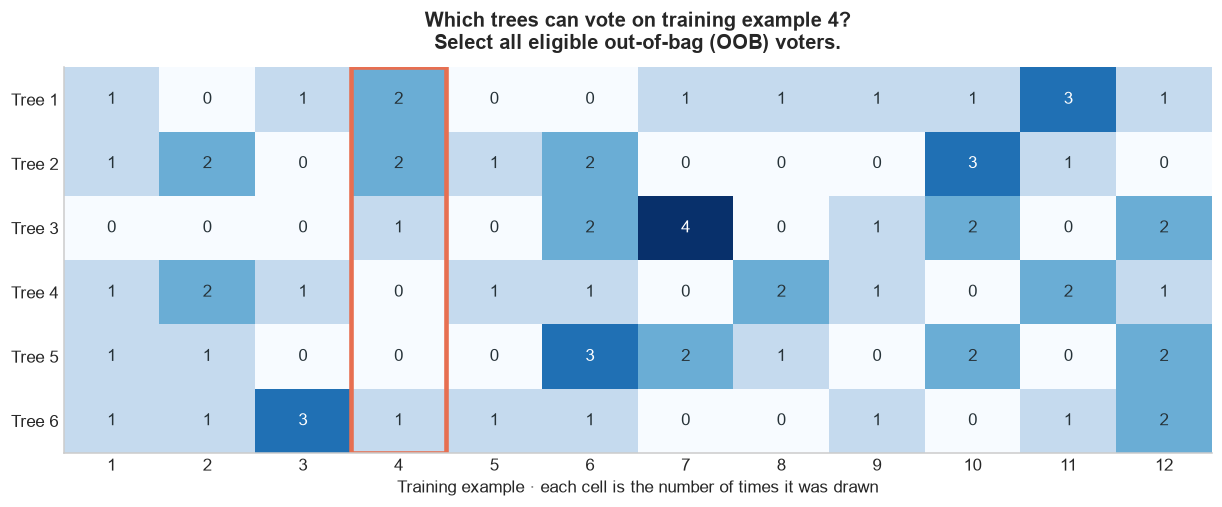

Button(description='Reveal OOB voters', icon='eye', layout=Layout(width='200px'), style=ButtonStyle())

HTML(value='')

In [63]:
def bootstrap_story():
    rng=np.random.default_rng(7)
    selected=3  # Keep training example 4 and all bootstrap samples fixed for the poll.
    usage=np.array([np.bincount(rng.choice(12,12,replace=True),minlength=12) for _ in range(6)])
    fig,ax=plt.subplots(figsize=(11,4.5),layout='constrained')
    ax.imshow(usage,cmap='Blues',vmin=0,vmax=4,aspect='auto')
    for row in range(6):
        for col in range(12): ax.text(col,row,str(usage[row,col]),ha='center',va='center',color='white' if usage[row,col]>=3 else INK)
    ax.add_patch(plt.Rectangle((selected-.5,-.5),1,6,fill=False,edgecolor=CORAL,lw=3))
    ax.set(xticks=range(12),xticklabels=range(1,13),yticks=range(6),yticklabels=[f'Tree {i+1}' for i in range(6)],
           xlabel='Training example · each cell is the number of times it was drawn',
           title='Which trees can vote on training example 4?\nSelect all eligible out-of-bag (OOB) voters.')
    ax.grid(False)
    plt.show()
    voters=' and '.join(map(str,np.flatnonzero(usage[:,selected]==0)+1))
    answer=widgets.HTML(value='')
    button=widgets.Button(description='Reveal OOB voters',icon='eye',layout=widgets.Layout(width='200px'))
    def reveal(_):
        show=not bool(answer.value)
        answer.value=(f'<p style="font-size:16px;color:{INK}"><strong>Trees {voters} can vote.</strong> '
                      'Both have zero draws for example 4, so neither trained on it. '
                      'The other four trees saw this example and are excluded from its OOB prediction.</p>') if show else ''
        button.description='Hide answer' if show else 'Reveal OOB voters'
        button.icon='eye-slash' if show else 'eye'
    button.on_click(reveal)
    display(button,answer)
    return button,answer

oob_reveal,oob_answer = bootstrap_story()

How often does an example get left out? With $n$ draws from $n$ examples, the probability is $(1-1/n)^n$, which approaches 36.8% as $n$ grows. So an example usually has only about a third of the forest available for its OOB prediction. With very few trees, it might have none.

This gives us an evaluation without holding out another fixed subset, but we still need a final test set: repeatedly choosing settings to improve the OOB score is still tuning. And bootstrap sampling isn't the only source of variety. Each split considers a fresh random set of features; a tree doesn't keep one feature subset for its whole life.

## 4. What Does the Next Batch of Trees Buy Us?

We saw that 200 trees can work much better together. How many of them do we actually need? Let's start with one tree and add more, without changing the trees we've already trained. Does each new batch help as much as the previous one?

We'll follow training, validation, and OOB accuracy. The OOB curve starts later because, with very few trees, some training examples haven't been left out of any tree's sample yet.

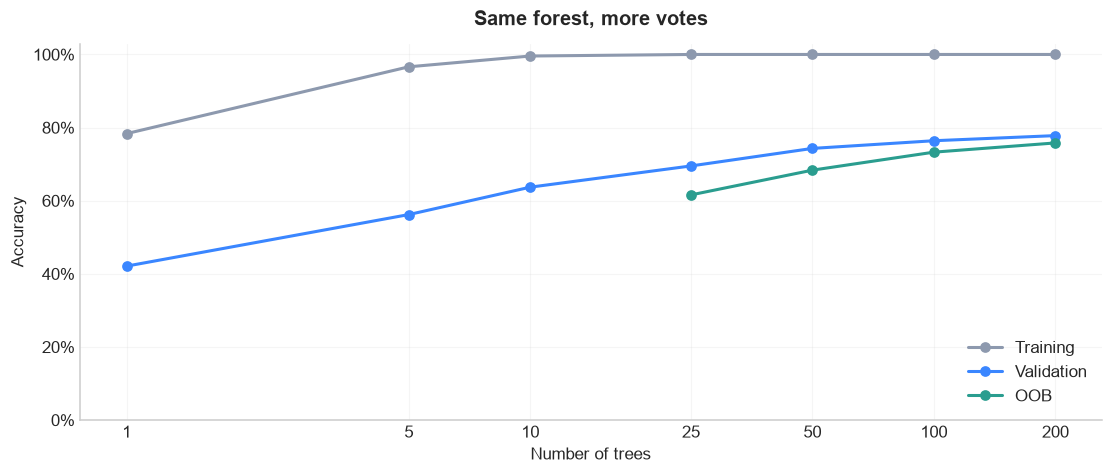

OOB points omitted when not every row has an eligible voter. Test data remain unopened.


In [64]:
sizes=[1,5,10,25,50,100,200]
train_sum=np.zeros((len(y_train),10)); val_sum=np.zeros((len(y_val),10))
oob_sum=np.zeros_like(train_sum); oob_n=np.zeros(len(y_train),int)
forest_curve=[]
for i,(tree,drawn) in enumerate(zip(forest.estimators_,forest.estimators_samples_),1):
    tp=tree.predict_proba(X_train); train_sum+=tp; val_sum+=tree.predict_proba(X_val)
    eligible=np.ones(len(y_train),bool); eligible[np.unique(drawn)]=False
    oob_sum[eligible]+=tp[eligible]; oob_n[eligible]+=1
    if i in sizes:
        forest_curve.append({'Trees':i,'Training':accuracy_score(y_train,train_sum.argmax(1)),
            'Validation':accuracy_score(y_val,val_sum.argmax(1)),
            'OOB':accuracy_score(y_train,oob_sum.argmax(1)) if (oob_n>0).all() else np.nan,
            'OOB coverage':(oob_n>0).mean()})
curve=pd.DataFrame(forest_curve)
fig,ax=plt.subplots(figsize=(10,4.2),layout='constrained')
for name,color in [('Training',MUTED),('Validation',BLUE),('OOB',TEAL)]:
    ax.plot(curve.Trees,curve[name],'o-',label=name,color=color,lw=2)
ax.set(xscale='log',xticks=sizes,xticklabels=sizes,ylim=(0,1.03),xlabel='Number of trees',ylabel='Accuracy',title='Same forest, more votes')
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.legend(loc='lower right')
plt.show()
print('OOB points omitted when not every row has an eligible voter. Test data remain unopened.')

Validation accuracy rises from 42.1% with one tree to 69.5% with 25. Going from 100 to 200 trees adds much less: 76.4% becomes 77.8%. More trees still help here, but the gains get smaller.

Training accuracy has already reached 100% by 25 trees, while validation accuracy keeps improving. We're combining more trees, not making each tree deeper. The OOB score finishes at 75.8%, compared with 77.8% on validation. They use different images, and each OOB prediction has only about 37% of the trees available, so we shouldn't expect the curves to match exactly.

## 5. One Image, Five Opinions

What if we ask five neural networks instead of 200 trees? We'll keep the same image features and train five small classifiers on them. Each sees the same training data but starts with different weights and a different order of examples. For each run, we keep the version with the lowest validation log loss, then average all five models' probabilities.

In [65]:
class Head(nn.Sequential):
    def __init__(self):
        super().__init__(nn.Linear(512,128),nn.ReLU(),nn.Dropout(.3),nn.Linear(128,10))

# Training needs gradients even if an earlier cell disabled them.
@torch.inference_mode(False)
@torch.enable_grad()
def fit_head(seed):
    torch.manual_seed(seed)
    model=Head().to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.001,weight_decay=.001)
    xt=torch.from_numpy(train_scaled).to(device); yt=torch.tensor(y_train,dtype=torch.long,device=device)
    xv=torch.from_numpy(val_scaled).to(device); yv=torch.tensor(y_val,dtype=torch.long,device=device)
    best,age,state=np.inf,0,None
    for epoch in range(60):
        model.train()
        for ids in torch.randperm(len(xt),device=device).split(128):
            loss=nn.functional.cross_entropy(model(xt[ids]),yt[ids])
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad(): score=nn.functional.cross_entropy(model(xv),yv).item()
        if score<best: best,age,state=score,epoch,copy.deepcopy(model.state_dict())
        if epoch-age>=8: break
    model.load_state_dict(state); model.eval()
    return model,{'Seed':seed,'Best epoch':age+1,'Epochs run':epoch+1,'Validation log loss':best}

head_runs=[fit_head(seed) for seed in [11,22,33,44,55]]
heads=[run[0] for run in head_runs]

def head_probabilities(features):
    x=torch.tensor(scaler.transform(features),dtype=torch.float32,device=device)
    with torch.inference_mode():
        return np.array([m(x).softmax(1).cpu().numpy() for m in heads])

val_probs=head_probabilities(X_val)
val_mean,val_within,val_disagreement=uncertainty(val_probs)
table([{'Predictor':f'Head {i+1}','Best epoch':head_runs[i][1]['Best epoch'],'Validation accuracy':accuracy_score(y_val,p.argmax(1)),'Log loss':log_loss(y_val,p)} for i,p in enumerate(val_probs)]
      +[{'Predictor':'Probability average','Best epoch':np.nan,'Validation accuracy':accuracy_score(y_val,val_mean.argmax(1)),'Log loss':log_loss(y_val,val_mean)}],
      {'Validation accuracy':'{:.1%}','Best epoch':'{:.0f}'})

Predictor,Best epoch,Validation accuracy,Log loss
Head 1,8,83.8%,0.513
Head 2,5,82.8%,0.505
Head 3,5,82.7%,0.506
Head 4,6,82.6%,0.507
Head 5,7,83.7%,0.498
Probability average,—,83.1%,0.492


Here the average isn't the most accurate: it gets 83.1% on validation, while the best individual gets 83.8%. But it has the lowest log loss. Choosing the right class and assigning useful probabilities aren't the same thing.

Let's look at what the average leaves out. **Explore this figure** lets us switch among five real validation images and see each model's probabilities. Do the models hesitate together, disagree with each other, or confidently give the same answer?

In [66]:
head_votes = val_probs.argmax(2)
head_counts = vote_counts(head_votes, len(class_names))
unanimous = head_counts.max(1) == len(heads)
mean_winner, confidence = val_mean.argmax(1), val_mean.max(1)
most_disagreement = int(val_disagreement.argmax())
nearby = unanimous & (abs(confidence-confidence[most_disagreement]) <= .03)
case_rules = [
    ('1 · Uncertain together', nearby, -val_disagreement),
    ('2 · Similar confidence, more disagreement', np.ones(len(y_val), bool), val_disagreement),
    ('3 · Votes and probabilities choose differently', (head_counts.max(1) >= 3) &
     (head_counts.argmax(1) == y_val) & (mean_winner != y_val), val_disagreement),
    ('4 · Confident agreement, label mismatch', unanimous & (mean_winner != y_val), confidence),
    ('5 · Confident agreement, label match', unanimous & (mean_winner == y_val), confidence)]
# Select only from validation; skip a category if a different run has no qualifying case.
interesting_cases = {name: int(np.where(mask, score, -np.inf).argmax())
                     for name, mask, score in case_rules if mask.any()}

def image_opinions(case=next(iter(interesting_cases))):
    def probability_label(value):
        return '>99.9%' if value > .999 else f'{value:.1%}'
    idx = interesting_cases[case]
    p = np.vstack([val_probs[:, idx], val_mean[idx]])
    classes = list(np.argsort(val_mean[idx])[-3:][::-1])
    if y_val[idx] not in classes: classes.append(int(y_val[idx]))
    other = [c for c in range(len(class_names)) if c not in classes]
    shown = np.column_stack([p[:, classes], p[:, other].sum(1)])
    labels = list(class_names[classes]) + ['Other classes']
    colors = [plt.get_cmap('tab10')(int(c)) for c in classes] + ['#CDD3DB']
    fig = plt.figure(figsize=(12.5, 6.2), layout='constrained')
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 3.4], height_ratios=[3.6, 1.2])
    photo = fig.add_subplot(gs[0, 0])
    photo.imshow(val_images[idx], interpolation='nearest'); photo.axis('off')
    photo.set_title(f'Dataset label: {class_names[y_val[idx]]}', fontsize=12)
    photo.text(.5, -.06, f'CIFAR-10 training image #{val_ids[idx]}\nHeld out for validation',
               ha='center', va='top', transform=photo.transAxes, fontsize=10, color=INK)
    ax = fig.add_subplot(gs[0, 1])
    rows = np.r_[np.arange(5, 0, -1), -.4]
    left = np.zeros(len(p))
    for values, label, color in zip(shown.T, labels, colors):
        ax.barh(rows, values, left=left, color=color, height=.62, label=label)
        for row, start, value in zip(rows, left, values):
            if value >= .10:
                ax.text(start+value/2, row, probability_label(value), ha='center', va='center', fontsize=10,
                        bbox={'fc':'white', 'ec':'none', 'alpha':.9, 'pad':1.5})
        left += values
    for row, values in zip(rows, p):
        ax.text(1.015, row, class_names[values.argmax()], va='center', fontsize=10,
                weight='bold' if row < 0 else 'normal')
    ax.axhline(.3, color=MUTED, lw=.8, alpha=.5)
    ax.set(yticks=rows, yticklabels=[f'Head {i+1}' for i in range(5)] + ['Average'],
           xlim=(0, 1), ylim=(-1, 5.6), xlabel='Predicted probability · every row sums to 100%')
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(loc='lower left', bbox_to_anchor=(0, 1.01), ncol=len(labels), fontsize=10,
              borderaxespad=0, columnspacing=1, handlelength=1)
    summary = fig.add_subplot(gs[1, 0]); summary.axis('off')
    winner = head_counts[idx].argmax()
    summary.text(0, .95, f'Top-class vote\n{class_names[winner]} · {head_counts[idx, winner]}/5 heads\n\n'
                 f'Probability average\n{class_names[mean_winner[idx]]} · {probability_label(confidence[idx])}',
                 va='top', fontsize=11, color=INK)
    ax = fig.add_subplot(gs[1, 1])
    within, disagreement = val_within[idx], val_disagreement[idx]
    ax.barh(0, within, height=.35, color=BLUE)
    ax.barh(0, disagreement, left=within, height=.35, color=TEAL)
    ax.text(0, .85, f'Within heads: {within:.4f}', color=BLUE, fontsize=11, weight='bold')
    disagreement_label = f'{disagreement:.4f}' if disagreement >= .0001 else '<0.0001'
    ax.text(1.05, .85, f'Disagreement: {disagreement_label}', color=TEAL, fontsize=11, weight='bold')
    ax.set(xlim=(0, np.log(10)), ylim=(-.5, 1.2), yticks=[], xticks=[0, 1, 2, np.log(10)],
           xticklabels=['0', '1', '2', 'log(10)'],
           xlabel='Total uncertainty (nats) · same scale for every image')
    fig.suptitle(case, fontsize=16, color=INK)
    plt.show()

explore(image_opinions, case=widgets.Dropdown(options=list(interesting_cases), description='Image',
        layout=widgets.Layout(width='490px')))

interactive(children=(Dropdown(description='Image', layout=Layout(width='490px'), options=('1 · Uncertain toge…

The first two averages look similarly confident: their winning classes get 52.9% and 52.0%. But the members tell different stories. In the first image, all five lean toward cat while keeping substantial probability on dog. In the second, one head strongly favors truck while the others favor automobile. Their full distributions aren't identical, and the disagreement is larger in the second case.

For the ship, three heads choose ship, yet the average narrowly chooses automobile. The strength of the probabilities changes the decision. The last two cases show confident agreement, with and without a match to the dataset label. That confidence alone can't tell us which is which; an unexpected mismatch is also worth checking for a labeling problem.

The blue part of the bottom bar measures how uncertain the individual heads are, on average. The green part measures the extra uncertainty from their disagreement. With probabilities $p_m$ and average $\bar p$,

$$\underbrace{H(\bar p)}_{\text{total}}=\underbrace{\frac1M\sum_m H(p_m)}_{\text{within members}}+\underbrace{\left[H(\bar p)-\frac1M\sum_m H(p_m)\right]}_{\text{disagreement}}.$$

We measure entropy in nats, using natural logs. Disagreement rises from 0.008 to 0.106 in the first two cases, but most uncertainty still comes from the heads themselves. These terms are often associated with aleatoric and epistemic uncertainty. Here, though, they describe what five models believe—not proof that an image is inherently ambiguous or that more data would resolve it. All five share the same feature extractor.

These examples were picked from validation to show useful contrasts, not how often each situation occurs. The plot groups less prominent classes into “Other classes”; it keeps their probability, and entropy uses all ten classes. Averaging also doesn't guarantee calibration: a predicted 90% need not mean 90% correct.

## Wrap-up

The forest worked because its members didn't always make the same mistakes; copying one model wouldn't have helped. Adding trees improved its predictions, though the gains got smaller. The five neural heads gave a more modest improvement, and their uncertainty helped us choose some cases to set aside. But they could still agree on a wrong answer, especially when the images changed. More models can improve a decision without making that decision automatically trustworthy.

### Sources

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) · [Random Forests and probability averaging](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) · [Deep Ensembles, Lakshminarayanan et al. (2017)](https://proceedings.neurips.cc/paper/2017/hash/9ef2ed4b7fd2c810847ffa5fa85bce38-Abstract.html) · [Uncertainty Under Dataset Shift, Ovadia et al. (2019)](https://proceedings.neurips.cc/paper/2019/hash/8558cb408c1d76621371888657d2eb1d-Abstract.html)

These papers explore ensembles and uncertainty in more depth. Our experiment uses a shared pretrained encoder and added pixel noise, so it doesn't reproduce their full setups.